# 02-clonotype-analysis

In [119]:
import scirpy as ir
import scanpy as sc
import muon as mu
import pandas as pd
import numpy as np
import json
from pathlib import Path

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')
DATA = Path("data/C143")

In [120]:
adata = sc.read_10x_h5(DATA / "GSM4339771_C143_filtered_feature_bc_matrix.h5")
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 20857 × 33539
    var: 'gene_ids', 'feature_types', 'genome'

In [121]:
adata_tcr = ir.io.read_10x_vdj(DATA / "GSM4385992_C143_filtered_contig_annotations.csv.gz")
adata_tcr

AnnData object with n_obs × n_vars = 2186 × 0
    uns: 'scirpy_version'
    obsm: 'airr'

In [122]:
mdata = mu.MuData({'gex': adata, 'airr': adata_tcr})
mdata

MuData object with n_obs × n_vars = 20859 × 33539
  2 modalities
    gex:	20857 × 33539
      var:	'gene_ids', 'feature_types', 'genome'
    airr:	2186 × 0
      uns:	'scirpy_version'
      obsm:	'airr'

In [123]:
sc.pp.filter_genes(mdata["gex"], min_cells=10)
sc.pp.filter_cells(mdata["gex"], min_genes=100)
mdata

MuData object with n_obs × n_vars = 20859 × 33539
  2 modalities
    gex:	20426 × 18167
      obs:	'n_genes'
      var:	'gene_ids', 'feature_types', 'genome', 'n_cells'
    airr:	2186 × 0
      uns:	'scirpy_version'
      obsm:	'airr'

In [124]:
sc.pp.normalize_per_cell(mdata["gex"])
sc.pp.log1p(mdata["gex"])
sc.pp.highly_variable_genes(mdata["gex"], flavor="cell_ranger", n_top_genes=5000)
sc.tl.pca(mdata["gex"])
sc.pp.neighbors(mdata["gex"])
sc.tl.umap(mdata["gex"])
mdata.update()
mdata

MuData object with n_obs × n_vars = 20428 × 18167
  2 modalities
    gex:	20426 × 18167
      obs:	'n_genes', 'n_counts'
      var:	'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg', 'pca', 'neighbors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'
    airr:	2186 × 0
      uns:	'scirpy_version'
      obsm:	'airr'

In [125]:
ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

In [126]:
mdata

MuData object with n_obs × n_vars = 20428 × 18167
  2 modalities
    gex:	20426 × 18167
      obs:	'n_genes', 'n_counts'
      var:	'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg', 'pca', 'neighbors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'
    airr:	2186 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing'
      uns:	'scirpy_version', 'chain_indices'
      obsm:	'airr', 'chain_indices'

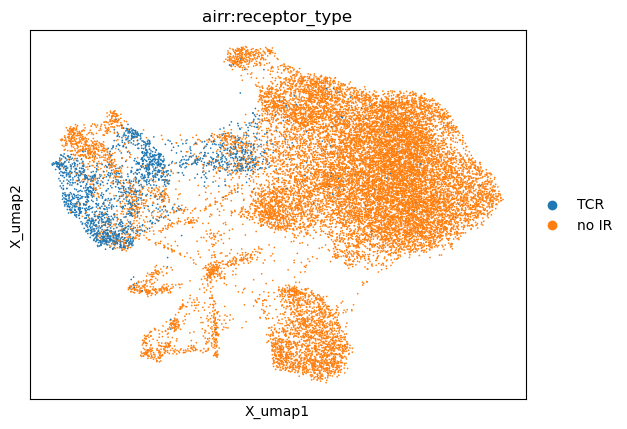

In [127]:
mu.pl.embedding(
  mdata,
  basis="gex:umap",
  color=["airr:receptor_type"],
  ncols=3,
  wspace=0.7,
)

In [128]:
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: ~np.isin(x, ["orphan VDJ", "orphan VJ"]))

In [129]:
obs = mdata['airr'].obs
filtered = obs.shape[0]
single_pair = obs[obs['chain_pairing'] == 'single pair'].shape[0]

print(f"Cells with TCR data after filtering: {filtered}")
print(f"Cells with single pair: {single_pair}")

Cells with TCR data after filtering: 1552
Cells with single pair: 1370


In [130]:
ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")
mdata

MuData object with n_obs × n_vars = 19794 × 18167
  2 modalities
    gex:	19794 × 18167
      obs:	'n_genes', 'n_counts'
      var:	'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'airr:receptor_type_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'
    airr:	1552 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size'
      uns:	'scirpy_version', 'chain_indices', 'ir_dist_nt_identity', 'clone_id'
      obsm:	'airr', 'chain_indices'

In [131]:
obs = mdata['airr'].obs
n_clonotypes = obs['clone_id'].unique().shape[0]
max_clonotype = obs['clone_id_size'].max().item()

print(f"Number of clonotypes: {n_clonotypes}")
print(f"Largest clonotype: {max_clonotype}")

Number of clonotypes: 1088
Largest clonotype: 25


In [132]:
output = {
  'n_single_pair': single_pair,
  'n_total': filtered,
  'n_clonotypes': n_clonotypes,
  'max_clonotype': max_clonotype
}

print(json.dumps(output, indent=2))

# with open('output.json', 'w') as f:
#     json.dump(output, f, indent=2)
# print('Results saved to output.json:')

{
  "n_single_pair": 1370,
  "n_total": 1552,
  "n_clonotypes": 1088,
  "max_clonotype": 25
}
